# Import libraries

In [1]:
# standard library
import os
import re
import sys
import subprocess
import importlib.util

# third-party
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from helper.io import load_data
from helper.geno import per_genotype_freq_per_human
from helper.pheno import make_pheno
from helper.plotting import show_biases
from helper.gwas import fit_line
from helper.effect_simulation import simulate_effects
from helper.pca import get_n_pcs
from helper.distance_to_snp import PC_distance_to_snp, pearson_distance_to_snp, marginal_estimation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
raw_geno, humans = load_data()
snp_names = list(raw_geno.columns)

# Standardize

In [3]:
majaf, hetaf, minaf = per_genotype_freq_per_human(raw_geno, pop=humans["populations"])
majaf_tot = majaf.mean() 
hetaf_tot = hetaf.mean()
minaf_tot = minaf.mean()
geno_std = raw_geno - (majaf_tot-minaf_tot)
geno_std =geno_std/hetaf_tot**0.5
geno_corr_std = raw_geno - (majaf-minaf)
geno_corr_std = geno_corr_std/hetaf_tot**0.5

# Create population bias

In [4]:
pheno = make_pheno(humans)

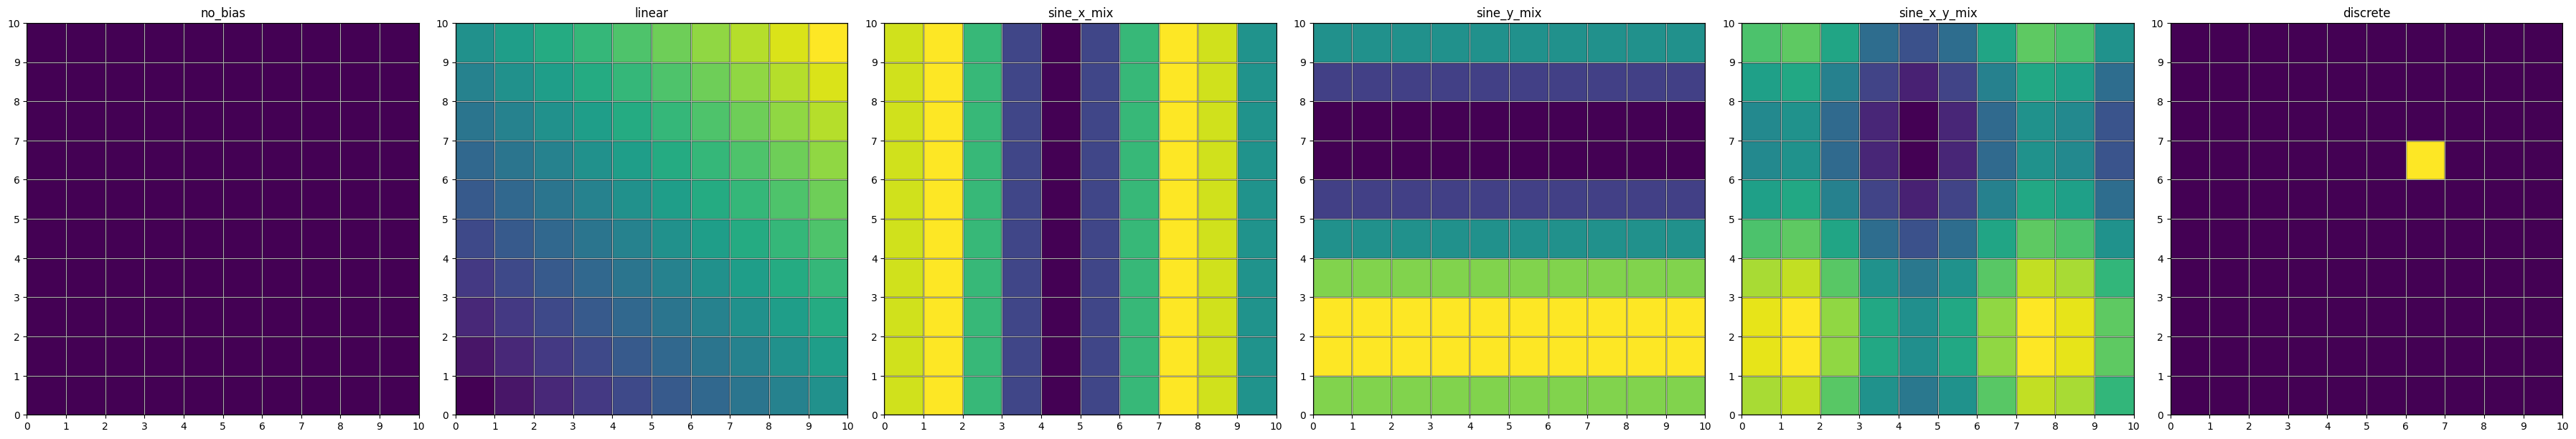

In [5]:
show_biases(pheno)

In [6]:
chosen_bias = "discrete"
#pheno[chosen_bias] = (pheno[chosen_bias] - pheno[chosen_bias].mean()) / pheno[chosen_bias].std()

In [7]:
qty_best = 4
qty_worst = 3
percentage_polygenic_noise = 20
effect_chosen_snp = 1
effect_most_corr_snps = 20
effect_least_corr_snps = 1
effect_polygenic_noise = 1

snps_simulated_meta_data = simulate_effects(
    geno_std, 
    pheno[chosen_bias],
    qty_best, 
    qty_worst, 
    percentage_polygenic_noise, 
    effect_chosen_snp, 
    effect_most_corr_snps, 
    effect_least_corr_snps, 
    effect_polygenic_noise)

In [8]:
perceived_slope = []

for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    slope, intercept, neglogp = fit_line(geno_std[snp], pheno_temp, covs=None)
    perceived_slope.append(slope)
snps_simulated_meta_data['raw_betas_std'] = perceived_slope
perceived_slope = []
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    slope, intercept, neglogp = fit_line(geno_corr_std[snp], pheno_temp, covs=None)
    perceived_slope.append(slope)
snps_simulated_meta_data['raw_betas_std_corr'] = perceived_slope

In [9]:
snps_simulated_meta_data.categories.unique()

array(['nul', 'polygenic noise', 'most correlated', 'chosen snp',
       'least correlated'], dtype=object)

In [10]:
# create pheno

In [11]:
snps_for_causal = snps_simulated_meta_data[
    snps_simulated_meta_data["categories"] == "chosen snp"
]

snps_for_poly = snps_simulated_meta_data[
    snps_simulated_meta_data["categories"].isin(
        ["polygenic noise", "most correlated", "least correlated"]
    )
]

In [12]:
pheno['causal_effect'] = 0.0
for idx, row in snps_for_causal.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    pheno['causal_effect'] += pheno_temp

pheno['poly_effect'] = 0.0
for idx, row in snps_for_poly.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    pheno['poly_effect'] += pheno_temp

effect_pop = 1
pheno['population_effect'] = pheno[chosen_bias]*effect_pop
pheno['total'] = pheno['causal_effect'] + pheno["poly_effect"] + pheno['population_effect']

In [13]:
snps_simulated_meta_data

,names,categories,raw_betas,raw_betas_std,raw_betas_std_corr
0,C_1_MAF_0.500,nul,0.0,0.0,0.0
1,C_2_MAF_0.500,nul,0.0,0.0,0.0
2,C_3_MAF_0.500,nul,0.0,0.0,0.0
3,C_4_MAF_0.500,nul,0.0,0.0,0.0
4,C_5_MAF_0.500,nul,0.0,0.0,0.0
...,...,...,...,...,...
7995,VR_7996_MAF_0.042,nul,0.0,0.0,0.0
7996,VR_7997_MAF_0.042,nul,0.0,0.0,0.0
7997,VR_7998_MAF_0.042,nul,0.0,0.0,0.0
7998,VR_7999_MAF_0.042,nul,0.0,0.0,0.0


In [14]:
marginals = []
estimated_betas = []
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    true_raw_beta = row.raw_betas_std
    
    slope_estimated_total, intercept_causal, neglogp_causal = fit_line(geno_std[snp], pheno['total'])
    estimated_betas.append(slope_estimated_total)
    slope_estimated_pop, intercept_causal, neglogp_causal = fit_line(geno_std[snp], pheno['population_effect'])
    marginal = slope_estimated_total-slope_estimated_pop-true_raw_beta
    marginals.append(marginal)
snps_simulated_meta_data['marginal_effect_std'] = marginals
snps_simulated_meta_data['estimated_betas_std'] = estimated_betas

marginals = []
estimated_betas = []

for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    true_raw_beta = row.raw_betas_std_corr
    
    slope_estimated_total, intercept_causal, neglogp_causal = fit_line(geno_corr_std[snp], pheno['total'])
    estimated_betas.append(slope_estimated_total)
    
    slope_estimated_pop, intercept_causal, neglogp_causal = fit_line(geno_corr_std[snp], pheno['population_effect'])
    marginal = slope_estimated_total-slope_estimated_pop-true_raw_beta
    marginals.append(marginal)
snps_simulated_meta_data['marginal_effect_std_corr'] = marginals
snps_simulated_meta_data['estimated_betas_std_corr'] = estimated_betas


In [15]:
snps_simulated_meta_data

,names,categories,raw_betas,raw_betas_std,raw_betas_std_corr,marginal_effect_std,estimated_betas_std,marginal_effect_std_corr,estimated_betas_std_corr
0,C_1_MAF_0.500,nul,0.0,0.0,0.0,0.101146,0.100899,0.108143,0.108143
1,C_2_MAF_0.500,nul,0.0,0.0,0.0,-0.257337,-0.253081,-0.088526,-0.088526
2,C_3_MAF_0.500,nul,0.0,0.0,0.0,0.175704,0.172101,0.125348,0.125348
3,C_4_MAF_0.500,nul,0.0,0.0,0.0,-0.250119,-0.245854,-0.063833,-0.063833
4,C_5_MAF_0.500,nul,0.0,0.0,0.0,0.239523,0.235584,0.083062,0.083062
...,...,...,...,...,...,...,...,...,...
7995,VR_7996_MAF_0.042,nul,0.0,0.0,0.0,-0.110674,-0.111224,-0.112501,-0.112501
7996,VR_7997_MAF_0.042,nul,0.0,0.0,0.0,-0.079525,-0.078422,-0.077306,-0.077306
7997,VR_7998_MAF_0.042,nul,0.0,0.0,0.0,-0.118485,-0.119063,-0.165362,-0.165362
7998,VR_7999_MAF_0.042,nul,0.0,0.0,0.0,0.010561,0.008233,-0.073047,-0.073047


In [16]:
# fit line
chosen_snp = list(snps_for_causal.names)[0]

In [17]:
slope_causal, intercept_causal, neglogp_causal = fit_line(geno_std[chosen_snp], pheno['causal_effect'])
slope_poly, intercept_poly, neglogp_poly = fit_line(geno_std[chosen_snp], pheno['poly_effect'])
slope_pop, intercept_pop, neglogp_pop = fit_line(geno_std[chosen_snp], pheno['population_effect'])
slope_total, intercept_total, neglogp_total = fit_line(geno_std[chosen_snp], pheno['total'])

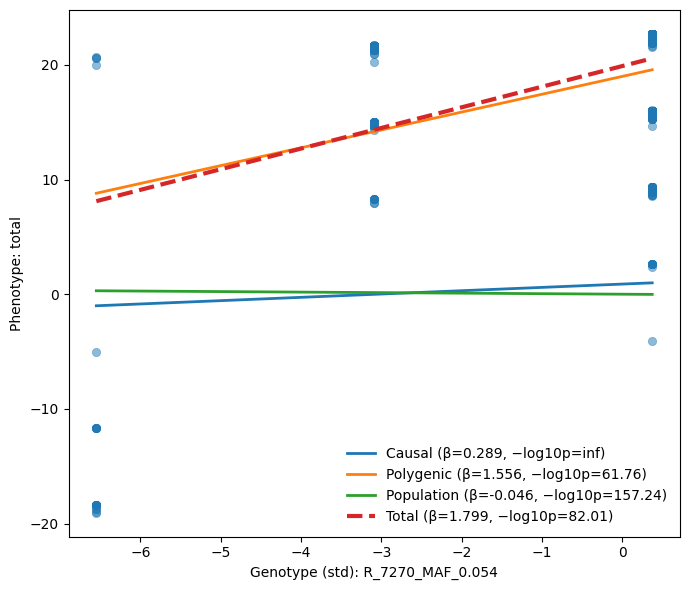

In [18]:

# Prepare data
x = geno_std[chosen_snp].values
df_plot = pd.DataFrame({
    "x": x,
    "total": pheno["total"],
})

# Base scatter plot
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot,
    x="x",
    y="total",
    alpha=0.5,
    edgecolor=None
)

# X range for fitted lines
x_line = np.linspace(x.min(), x.max(), 200)

# Plot fitted lines
plt.plot(
    x_line,
    slope_causal * x_line + intercept_causal,
    label=f"Causal (β={slope_causal:.3f}, −log10p={neglogp_causal:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_poly * x_line + intercept_poly,
    label=f"Polygenic (β={slope_poly:.3f}, −log10p={neglogp_poly:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_pop * x_line + intercept_pop,
    label=f"Population (β={slope_pop:.3f}, −log10p={neglogp_pop:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_total * x_line + intercept_total,
    label=f"Total (β={slope_total:.3f}, −log10p={neglogp_total:.2f})",
    linewidth=3,
    linestyle="--"
)

# Labels & styling
plt.xlabel(f"Genotype (std): {chosen_snp}")
plt.ylabel("Phenotype: total")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [19]:
# estimate betas_poly

In [20]:
n_pcs = 25
snps_pcs = get_n_pcs(geno_std.T, n_pcs)

In [21]:
estimated_margs=[]
X = geno_std.to_numpy(dtype=float)                 # (n_samples, n_snps)
cols = geno_std.columns
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    #pc_df = PC_distance_to_snp(geno_std, snps_pcs, snp, n_pcs=25)
    pear_df = pearson_distance_to_snp(X, cols, snp)
    estimated_margs.append(marginal_estimation(pear_df, snps_simulated_meta_data))

In [22]:
snps_simulated_meta_data['estimated_marginal_effects_std_Pearson'] = estimated_margs

In [23]:
estimated_margs=[]
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    pc_df = PC_distance_to_snp(geno_std, snps_pcs, snp, n_pcs=25)
    #pear_df = pearson_distance_to_snp(geno_std, snps_pcs, chosen_snp)
    estimated_margs.append(marginal_estimation(pc_df, snps_simulated_meta_data))
snps_simulated_meta_data['estimated_marginal_effects_std_PCA'] = estimated_margs

In [24]:
snps_simulated_meta_data

,names,categories,raw_betas,raw_betas_std,raw_betas_std_corr,marginal_effect_std,estimated_betas_std,marginal_effect_std_corr,estimated_betas_std_corr,estimated_marginal_effects_std_Pearson,estimated_marginal_effects_std_PCA
0,C_1_MAF_0.500,nul,0.0,0.0,0.0,0.101146,0.100899,0.108143,0.108143,41.962936,49.552350
1,C_2_MAF_0.500,nul,0.0,0.0,0.0,-0.257337,-0.253081,-0.088526,-0.088526,-10.755415,-14.252699
2,C_3_MAF_0.500,nul,0.0,0.0,0.0,0.175704,0.172101,0.125348,0.125348,46.168691,47.019668
3,C_4_MAF_0.500,nul,0.0,0.0,0.0,-0.250119,-0.245854,-0.063833,-0.063833,-10.969282,-14.494662
4,C_5_MAF_0.500,nul,0.0,0.0,0.0,0.239523,0.235584,0.083062,0.083062,34.836916,40.101559
...,...,...,...,...,...,...,...,...,...,...,...
7995,VR_7996_MAF_0.042,nul,0.0,0.0,0.0,-0.110674,-0.111224,-0.112501,-0.112501,-4.352392,17.264177
7996,VR_7997_MAF_0.042,nul,0.0,0.0,0.0,-0.079525,-0.078422,-0.077306,-0.077306,9.475443,22.294226
7997,VR_7998_MAF_0.042,nul,0.0,0.0,0.0,-0.118485,-0.119063,-0.165362,-0.165362,3.831128,19.528002
7998,VR_7999_MAF_0.042,nul,0.0,0.0,0.0,0.010561,0.008233,-0.073047,-0.073047,-5.104810,16.833530


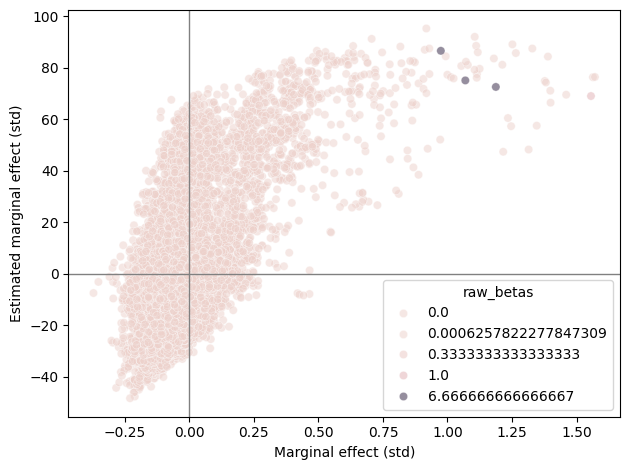

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=snps_simulated_meta_data,
    x="marginal_effect_std",
    y="estimated_marginal_effects_std_Pearson",
    hue = "raw_betas",
    alpha=0.5
)

plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("Marginal effect (std)")
plt.ylabel("Estimated marginal effect (std)")
plt.tight_layout()
plt.show()


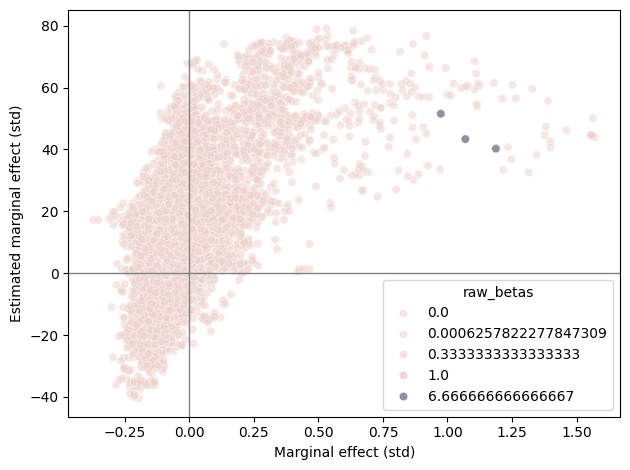

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=snps_simulated_meta_data,
    x="marginal_effect_std",
    y="estimated_marginal_effects_std_PCA",
    hue="raw_betas",
    alpha=0.5
)

plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("Marginal effect (std)")
plt.ylabel("Estimated marginal effect (std)")
plt.tight_layout()
plt.show()


In [27]:
n_pcs = 25
snps_pcs = get_n_pcs(geno_corr_std.T, n_pcs)
estimated_margs=[]
X = geno_corr_std.to_numpy(dtype=float)                 # (n_samples, n_snps)
cols = geno_corr_std.columns
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    #pc_df = PC_distance_to_snp(geno_std, snps_pcs, snp, n_pcs=25)
    pear_df = pearson_distance_to_snp(X, cols, snp)
    estimated_margs.append(marginal_estimation(pear_df, snps_simulated_meta_data))
snps_simulated_meta_data['estimated_marginal_effects_std_Pearson_corr'] = estimated_margs
estimated_margs=[]
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    pc_df = PC_distance_to_snp(geno_corr_std, snps_pcs, snp, n_pcs=25)
    #pear_df = pearson_distance_to_snp(geno_std, snps_pcs, chosen_snp)
    estimated_margs.append(marginal_estimation(pc_df, snps_simulated_meta_data))
snps_simulated_meta_data['estimated_marginal_effects_std_PCA_corr'] = estimated_margs

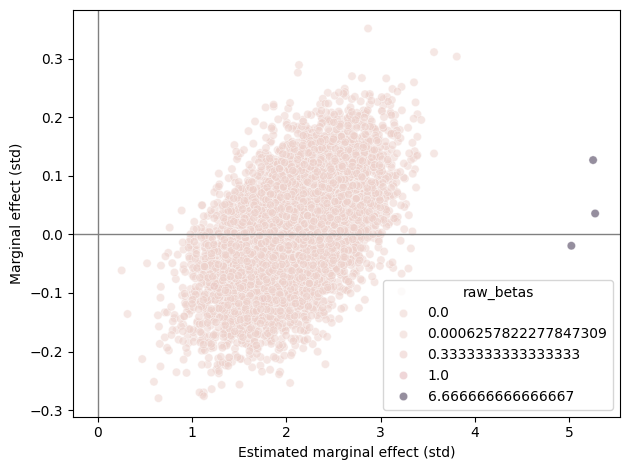

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=snps_simulated_meta_data,
    x="estimated_marginal_effects_std_Pearson_corr",
    y="marginal_effect_std_corr",
    hue = "raw_betas",
    alpha=0.5
)

plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("Estimated marginal effect (std)")
plt.ylabel("Marginal effect (std)")
plt.tight_layout()
plt.show()


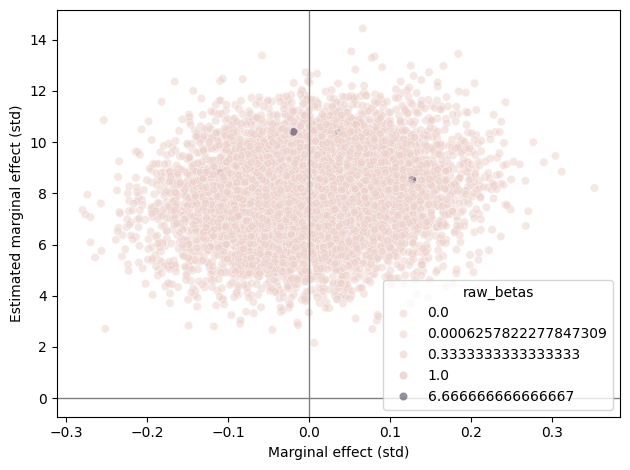

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=snps_simulated_meta_data,
    x="marginal_effect_std_corr",
    y="estimated_marginal_effects_std_PCA_corr",
    hue = "raw_betas",
    alpha=0.5
)

plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("Marginal effect (std)")
plt.ylabel("Estimated marginal effect (std)")
plt.tight_layout()
plt.show()


In [34]:
cmp_df = pc_df.merge(
    pear_df,
    on="snp",
    suffixes=("_pc", "_pearson")
)


In [35]:
snps_simulated_meta_data

,names,categories,raw_betas,raw_betas_std,raw_betas_std_corr,estimated_betas_std,estimated_betas_std_corr
0,C_1_MAF_0.500,nul,0.000000,0.000000,0.000000,0.099063,0.108357
1,C_2_MAF_0.500,nul,0.000000,0.000000,0.000000,-0.251021,-0.088580
2,C_3_MAF_0.500,nul,0.000000,0.000000,0.000000,0.171992,0.125558
3,C_4_MAF_0.500,nul,0.000000,0.000000,0.000000,-0.244035,-0.064055
4,C_5_MAF_0.500,nul,0.000000,0.000000,0.000000,0.233868,0.083514
...,...,...,...,...,...,...,...
7995,VR_7996_MAF_0.042,nul,0.000000,0.000000,0.000000,-0.110699,-0.112208
7996,VR_7997_MAF_0.042,nul,0.000000,0.000000,0.000000,-0.078170,-0.076840
7997,VR_7998_MAF_0.042,nul,0.000000,0.000000,0.000000,-0.119847,-0.165328
7998,VR_7999_MAF_0.042,polygenic noise,0.000626,0.000176,0.000176,0.008110,-0.073042


In [36]:
pc_df

,snp,distance,proximity
1129,C_1130_MAF_0.357,70.426522,0.000000
207,C_208_MAF_0.474,69.031590,0.019807
1155,C_1156_MAF_0.355,68.190019,0.031757
1049,C_1050_MAF_0.368,68.155525,0.032246
1069,C_1070_MAF_0.365,67.607849,0.040023
...,...,...,...
6190,R_6191_MAF_0.064,5.795299,0.917711
6884,R_6885_MAF_0.057,5.703025,0.919022
6349,R_6350_MAF_0.062,5.630070,0.920058
6970,R_6971_MAF_0.056,4.621327,0.934381


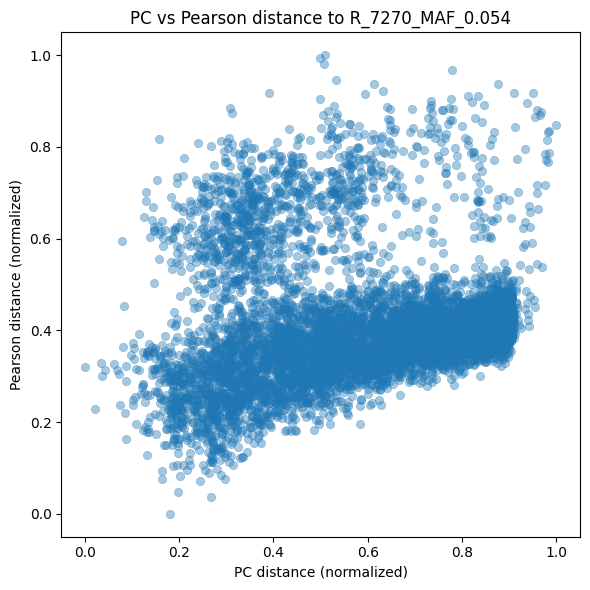

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=cmp_df,
    x="proximity_pc",
    y="proximity_pearson",
    alpha=0.4,
    edgecolor=None
)

plt.xlabel("PC distance (normalized)")
plt.ylabel("Pearson distance (normalized)")
plt.title(f"PC vs Pearson distance to {chosen_snp}")
plt.tight_layout()
plt.show()


In [75]:
# corrected

In [76]:
slope_causal, intercept_causal, neglogp_causal = fit_line(geno_corr_std[chosen_snp], pheno['causal_effect'])
slope_poly, intercept_poly, neglogp_poly = fit_line(geno_corr_std[chosen_snp], pheno['poly_effect'])
slope_pop, intercept_pop, neglogp_pop = fit_line(geno_corr_std[chosen_snp], pheno['population_effect'])
slope_total, intercept_total, neglogp_total = fit_line(geno_corr_std[chosen_snp], pheno['total'])

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
x = geno_corr_std[chosen_snp].values
df_plot = pd.DataFrame({
    "x": x,
    "total": pheno["total"],
})

# Base scatter plot
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot,
    x="x",
    y="total",
    alpha=0.5,
    edgecolor=None
)

# X range for fitted lines
x_line = np.linspace(x.min(), x.max(), 200)

# Plot fitted lines
plt.plot(
    x_line,
    slope_causal * x_line + intercept_causal,
    label=f"Causal (β={slope_causal:.3f}, −log10p={neglogp_causal:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_poly * x_line + intercept_poly,
    label=f"Polygenic (β={slope_poly:.3f}, −log10p={neglogp_poly:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_pop * x_line + intercept_pop,
    label=f"Population (β={slope_pop:.3f}, −log10p={neglogp_pop:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_total * x_line + intercept_total,
    label=f"Total (β={slope_total:.3f}, −log10p={neglogp_total:.2f})",
    linewidth=3,
    linestyle="--"
)

# Labels & styling
plt.xlabel(f"Genotype (std): {chosen_snp}")
plt.ylabel("Phenotype: total")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


NameError: name 'geno_corr_std' is not defined